### Visual Data Analysis

#### Objectives
* Determine average image dimensions across the dataset.
* Calculate average and variability images for healthy and powdery mildew leaves.
* Compute the visual difference between average healthy and average powdery mildew images.
* Create image montages for both classes to embed in the Streamlit application.

#### Inputs
* Processed training images: `inputs/datasets/cherry_leaves_split/train/`

#### Outputs
* Saved mean/variability image arrays and plots in `outputs/v1/`.
* Image montages saved for Streamlit dashboard rendering.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

train_path = 'inputs/datasets/cherry_leaves_split/train'
dim1, dim2 = [], []

for image_path in glob.glob(train_path + '/*/*.jpg') + glob.glob(train_path + '/*/*.png'):
    img = Image.open(image_path)
    weight, height = img.size
    dim1.append(weight)
    dim2.append(height)

avg_dim1 = int(np.mean(dim1))
avg_dim2 = int(np.mean(dim2))

print(f"Average Image Width: {avg_dim1}px")
print(f"Average Image Height: {avg_dim2}px")

# Target image shape for CNN model input
image_shape = (avg_dim1, avg_dim2, 3)

Average Image Width: 256px
Average Image Height: 256px


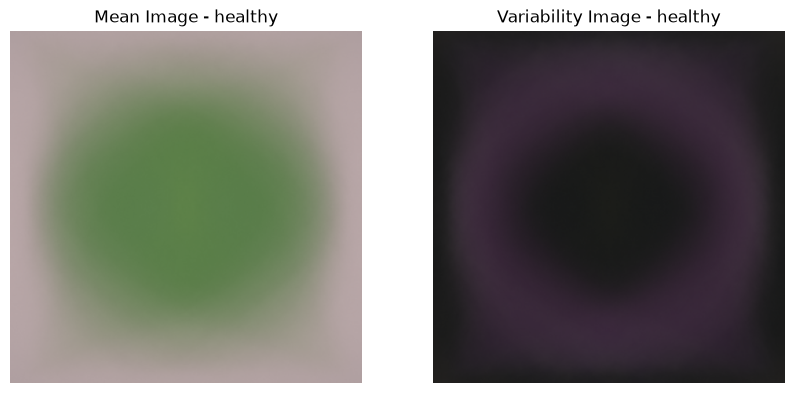

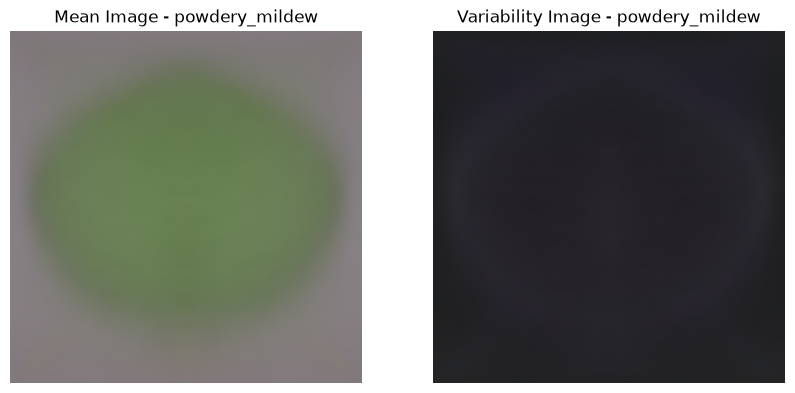

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array

output_dir = 'outputs/v1'
os.makedirs(output_dir, exist_ok=True)

def mean_variability_images(data_dir, class_label, img_shape=(256, 256)):
    images = []
    class_path = os.path.join(data_dir, class_label)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path, target_size=img_shape)
        img_array = img_to_array(img) / 255.0
        images.append(img_array)
        
    images_array = np.array(images)
    mean_img = np.mean(images_array, axis=0)
    std_img = np.std(images_array, axis=0)
    
    # Save arrays
    np.save(os.path.join(output_dir, f'mean_{class_label}.npy'), mean_img)
    np.save(os.path.join(output_dir, f'variability_{class_label}.npy'), std_img)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(mean_img)
    axes[0].set_title(f'Mean Image - {class_label}')
    axes[0].axis('off')
    
    axes[1].imshow(std_img)
    axes[1].set_title(f'Variability Image - {class_label}')
    axes[1].axis('off')
    
    plt.savefig(os.path.join(output_dir, f'mean_var_{class_label}.png'), bbox_inches='tight')
    plt.show()

mean_variability_images(train_path, 'healthy')
mean_variability_images(train_path, 'powdery_mildew')

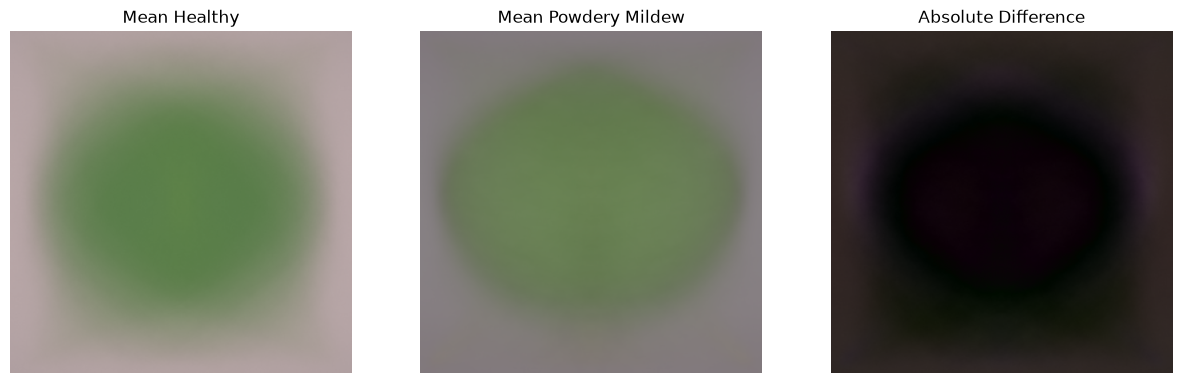

In [3]:
mean_healthy = np.load(os.path.join(output_dir, 'mean_healthy.npy'))
mean_mildew = np.load(os.path.join(output_dir, 'mean_powdery_mildew.npy'))

diff_between_means = mean_healthy - mean_mildew
diff_between_means_abs = np.abs(diff_between_means)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mean_healthy)
axes[0].set_title('Mean Healthy')
axes[0].axis('off')

axes[1].imshow(mean_mildew)
axes[1].set_title('Mean Powdery Mildew')
axes[1].axis('off')

axes[2].imshow(diff_between_means_abs)
axes[2].set_title('Absolute Difference')
axes[2].axis('off')

plt.savefig(os.path.join(output_dir, 'mean_difference.png'), bbox_inches='tight')
plt.show()

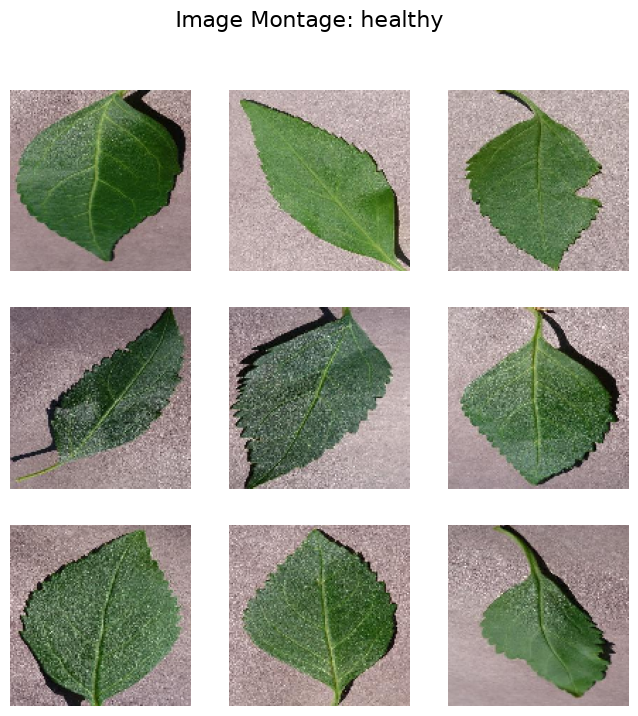

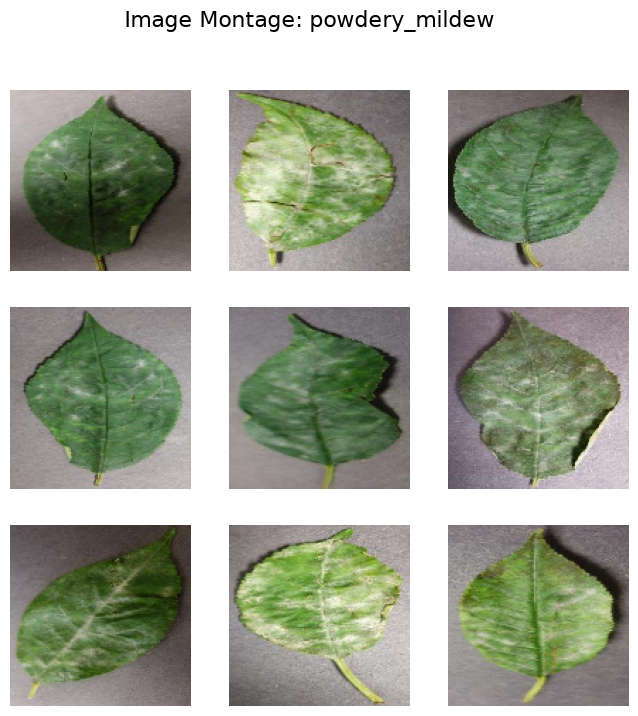

In [4]:
import random

def create_montage(data_dir, class_label, grid_size=(3, 3), img_shape=(128, 128)):
    class_path = os.path.join(data_dir, class_label)
    images_list = os.listdir(class_path)
    selected_images = random.sample(images_list, grid_size[0] * grid_size[1])
    
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(8, 8))
    fig.suptitle(f'Image Montage: {class_label}', fontsize=16)
    
    for i, img_name in enumerate(selected_images):
        row, col = i // grid_size[1], i % grid_size[1]
        img = load_img(os.path.join(class_path, img_name), target_size=img_shape)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
    plt.savefig(os.path.join(output_dir, f'montage_{class_label}.png'), bbox_inches='tight')
    plt.show()

create_montage(train_path, 'healthy')
create_montage(train_path, 'powdery_mildew')